In [1]:
pip install yfinance pandas ta seaborn matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed



Pearson Correlation:
 rsi           NaN
sma_20        NaN
macd          NaN
bollinger_h   NaN
bollinger_l   NaN
dtype: float64

LASSO Coefficients:
 rsi           -2.255776e-17
sma_20        -0.000000e+00
macd           0.000000e+00
bollinger_h   -0.000000e+00
bollinger_l   -0.000000e+00
dtype: float64

Cross Validation Scores:
 [0.52266667 0.54133333 0.552      0.57066667 0.51466667 0.53066667
 0.58133333 0.512      0.51069519 0.55882353]
Mean Accuracy: 0.5395


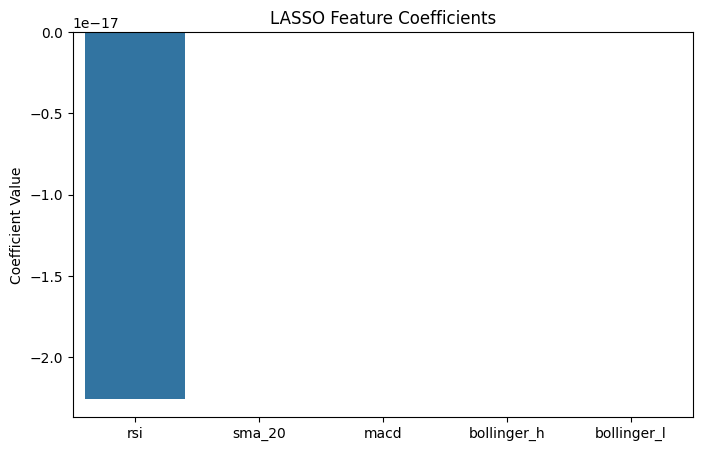

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


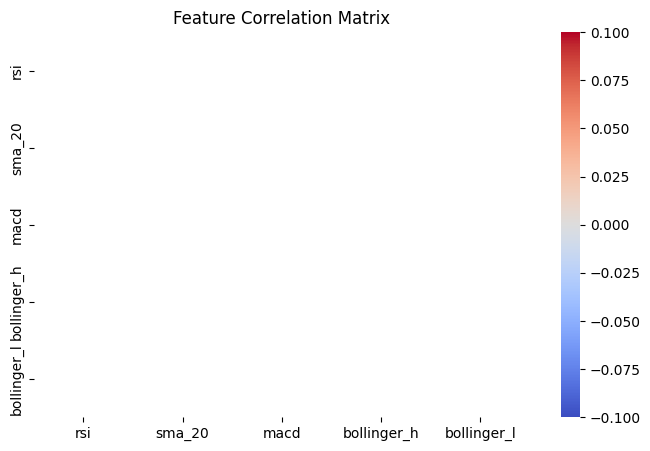

In [2]:
import yfinance as yf
import pandas as pd
import ta
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neural_network import MLPClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Download IVV ETF data
df = yf.download("IVV", start="2010-01-01", end="2024-12-31")
df = df.dropna()

close = df['Close'].squeeze()  # or df['Close'] (never df[['Close']])

# Step 2: Compute technical indicators
df['rsi'] = ta.momentum.RSIIndicator(close=close).rsi()
df['sma_20'] = ta.trend.SMAIndicator(close=close, window=20).sma_indicator()
df['macd'] = ta.trend.MACD(close=close).macd()

# Bollinger Bands
bb = ta.volatility.BollingerBands(close=close)
df['bollinger_h'] = bb.bollinger_hband()
df['bollinger_l'] = bb.bollinger_lband()

# Step 3: Create binary classification target
df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.dropna()

# Step 4: Normalize features
features = ['rsi', 'sma_20', 'macd', 'bollinger_h', 'bollinger_l']
X = df[features]
y = df['target']
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Pearson Correlation
corr_matrix = pd.DataFrame(X, columns=features).corrwith(y)
print("\nPearson Correlation:\n", corr_matrix)

# Step 6: LASSO Feature Selection
lasso = LassoCV(cv=5).fit(X_scaled, y)
lasso_coef = pd.Series(lasso.coef_, index=features)
print("\nLASSO Coefficients:\n", lasso_coef)

# Step 7: MLP Classifier with 10-Fold Cross Validation
mlp = MLPClassifier(hidden_layer_sizes=(len(features) + 1) // 2, max_iter=500, random_state=1)
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(mlp, X_scaled, y, cv=kfold, scoring='accuracy')
print("\nCross Validation Scores:\n", cv_scores)
print("Mean Accuracy: {:.4f}".format(cv_scores.mean()))

# Step 8: Visualization
plt.figure(figsize=(8, 5))
sns.barplot(x=features, y=lasso_coef.values)
plt.title("LASSO Feature Coefficients")
plt.ylabel("Coefficient Value")
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(pd.DataFrame(X, columns=features).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()



                                 Open        High         Low       Close  \
Date                                                                        
2024-04-24 00:00:00-04:00  165.757307  168.504345  165.428871  168.225662   
2024-04-25 00:00:00-04:00  168.733275  169.808201  167.359755  169.091583   
2024-04-26 00:00:00-04:00  169.081625  170.534755  168.384902  168.504349   
2024-04-29 00:00:00-04:00  172.555207  175.202709  172.286487  172.684601   
2024-04-30 00:00:00-04:00  172.515396  174.167598  169.201044  169.529495   

                             Volume  Dividends  Stock Splits  
Date                                                          
2024-04-24 00:00:00-04:00  48251800        0.0           0.0  
2024-04-25 00:00:00-04:00  50558300        0.0           0.0  
2024-04-26 00:00:00-04:00  44838400        0.0           0.0  
2024-04-29 00:00:00-04:00  68169400        0.0           0.0  
2024-04-30 00:00:00-04:00  65934800        0.0           0.0  
                   

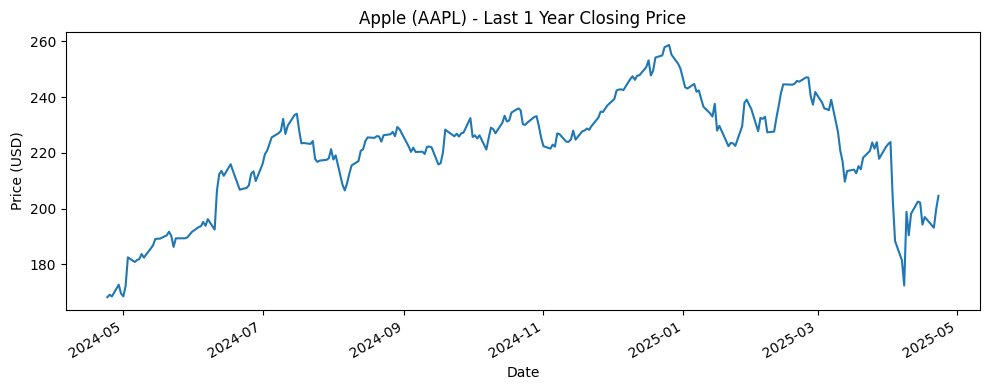

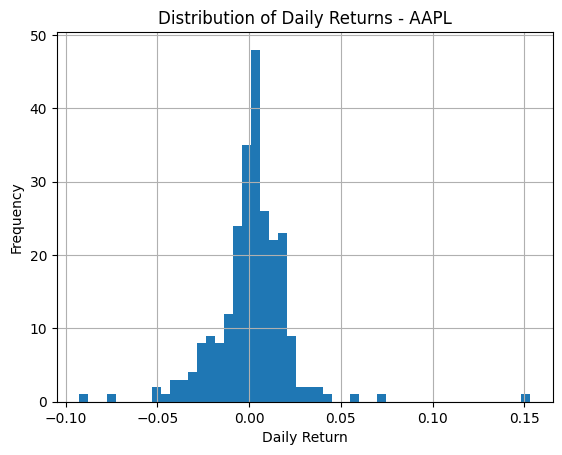

In [3]:
import yfinance as yf
import pandas as pd

# Fetch historical stock data for Apple
ticker = yf.Ticker("AAPL")
hist = ticker.history(period="1y")

# Fetch basic info and financials
info = ticker.info
income_stmt = ticker.financials
balance_sheet = ticker.balance_sheet

# Structure into DataFrame
print(hist.head())
print(income_stmt.head())


import matplotlib.pyplot as plt

# Plot closing price
hist['Close'].plot(title="Apple (AAPL) - Last 1 Year Closing Price", figsize=(10, 4))
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

# Calculate daily returns
hist['Daily Return'] = hist['Close'].pct_change()
hist['Daily Return'].hist(bins=50)
plt.title("Distribution of Daily Returns - AAPL")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()
